In [1]:
"""
In order to run the code as is, you will need scipy, pandas and tqdm installed
(although tqdm is only needed for the progress bar, and pandas is only for the autocorrelation function)
All of these can be installed (on linux) from the command interface using 'pip'
"""

import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from MHrank import MH_sample
from eprank import exprop
import pandas
from cw2 import sorted_barplot

In [2]:
from scipy.stats import norm
import pandas as pd

def prob_skill_higher(mu1, var1, mu2, var2):
    """calculate P(skill1 > skill2)"""
    # w1 - w2 ~ N(mu1 - mu2, var1 + var2)
    return norm.cdf((mu1 - mu2) / np.sqrt(var1 + var2))

def prob_player_wins(mu1, var1, mu2, var2):
    """calculate P(Player 1 wins against Player 2)"""
    return norm.cdf((mu1 - mu2) / np.sqrt(var1 + var1 + 1.0))

# index
def find_player_indices(W, names):
    indices = []
    player_names = [str(p[0]) for p in W] if W.ndim > 1 else W.flatten().astype(str)

    for name in names:
        try:
            idx = [i for i, x in enumerate(player_names) if name in x][0]
            indices.append(idx)
        except IndexError:
            print(f"Warning: Player {name} not found.")
            indices.append(-1) # Placeholder for missing player
    return indices

We first need to load the data, stored in "tennis_data.mat". The data consists of an array, $W$ containing the names of each player, and an array, G, containing the results of all of the matches in the season.

In [3]:
# set seed for reproducibility
np.random.seed(0)
# load data
data = sio.loadmat('tennis_data.mat')
# Array containing the names of each player
W = data['W']
# loop over array to format more nicely
for i, player in enumerate(W):
    W[i] = player[0]
# Array of size num_games x 2. The first entry in each row is the winner of game i, the second is the loser
games = data['G'] - 1
num_players = W.shape[0]
num_games = games.shape[0]

# MCMC sampling (this may take a minute)

In [4]:
# number of iterations -- the more the better!
num_its = 5000
# perform Metropolis MCMC sampling, skill samples is an num_players x num_samples array
skill_samples = MH_sample(games, num_players, num_its)

# discard the first half of the samples (burn-in period)
# skill_samples = skill_samples[:,num_iters//2:]

100%|██████████| 5000/5000 [04:44<00:00, 17.60it/s]

MCMC Acceptance Rate: 30.95%


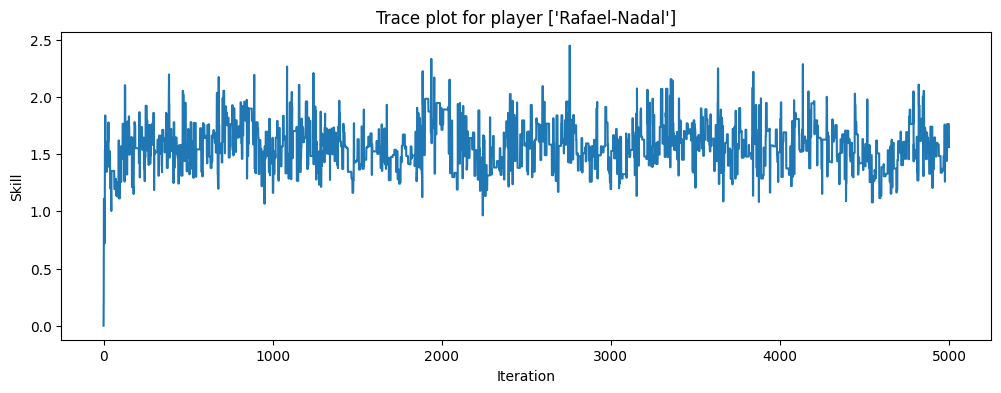

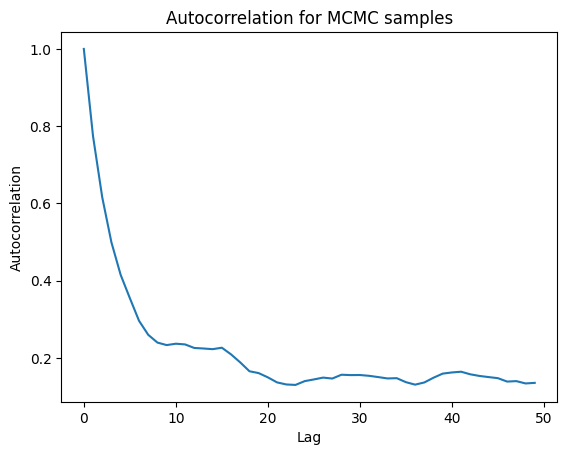

In [5]:
# Trace Plot
plt.figure(figsize=(12, 4))
# choose a player
player_idx = 0
plt.plot(skill_samples[player_idx, :])
plt.title(f"Trace plot for player {W[player_idx]}")
plt.xlabel("Iteration")
plt.ylabel("Skill")
plt.show()

# remove Burn-in
burn_in = 500
clean_samples = skill_samples[:, burn_in:]

# autocorrelation
i = 0 # Djokovic
autocor = np.zeros(50)
for t in range(50):
    autocor[t] = pd.Series(clean_samples[i,:]).autocorr(lag=t)
plt.plot(autocor)
plt.title("Autocorrelation for MCMC samples")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

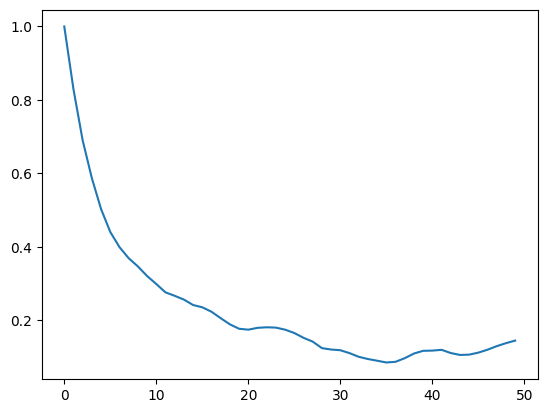

In [6]:
# plotting the autocorrelation function for player i
i = 5
autocor = np.zeros(50)
for t in range(50):
    autocor[t]=pandas.Series.autocorr(pandas.Series(skill_samples[i,:]),lag=t)
plt.plot(autocor)

# Expectation propagation ranking

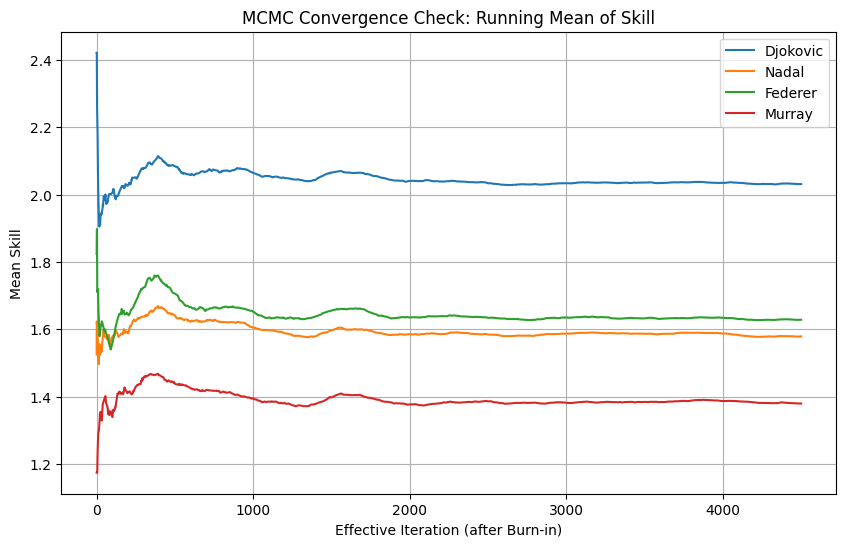

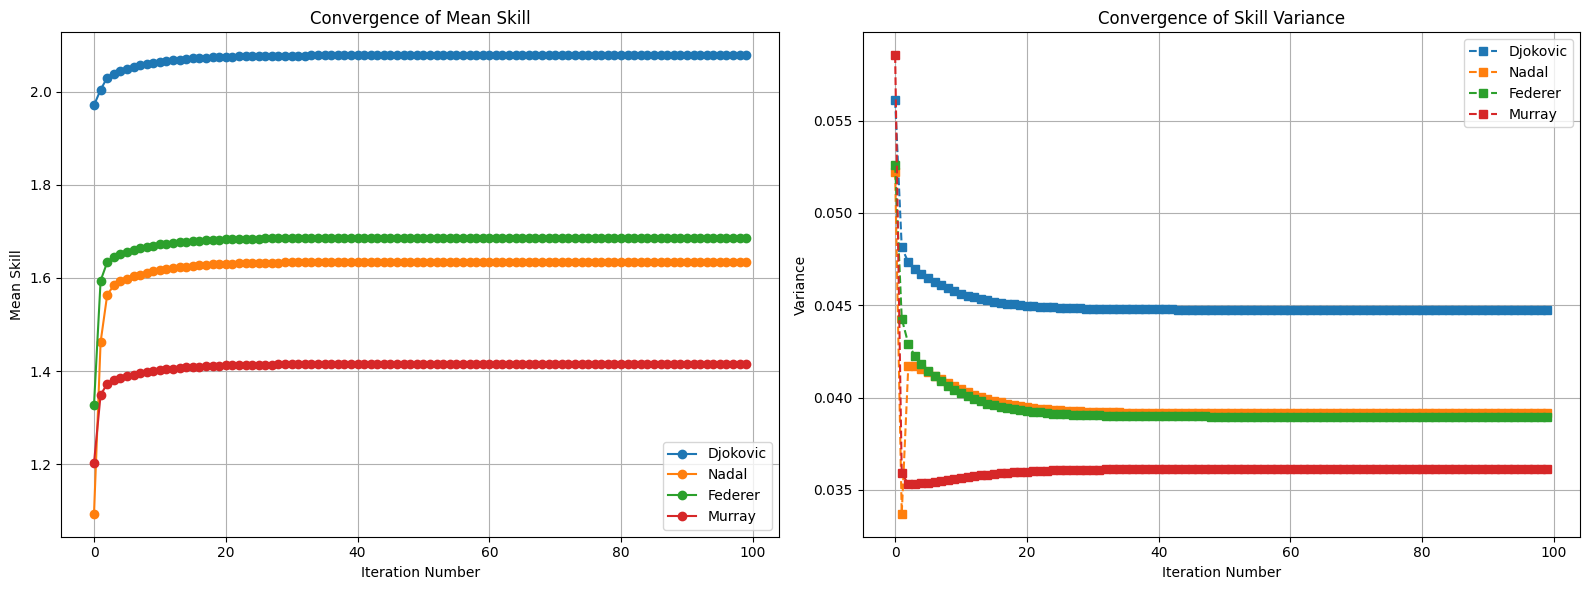

In [7]:
# run message passing algorithm, returns mean and variance for each player
#ep_mean, ep_var = exprop(games, num_players, num_its = 3).T

# MCMC Running Mean Plot ===

# clean_samples
#num_its = 4000
#skill_samples = MH_sample(games, num_players, num_its)
#burn_in = 500
clean_samples = skill_samples[:, burn_in:]

top4_names = ["Djokovic", "Nadal", "Federer", "Murray"]
top4_idx = find_player_indices(W, top4_names)
top4_samples = clean_samples[top4_idx, :]

plt.figure(figsize=(10, 6))

for i, name in enumerate(top4_names):
    running_mean = np.cumsum(top4_samples[i]) / np.arange(1, len(top4_samples[i]) + 1)
    plt.plot(running_mean, label=name)

plt.title("MCMC Convergence Check: Running Mean of Skill")
plt.xlabel("Effective Iteration (after Burn-in)")
plt.ylabel("Mean Skill")
plt.legend()
plt.grid(True)
plt.show()

# === Task (b) EP Convergence Check ===

ep_result_full, _, ep_history_full = exprop(games, num_players, num_its=100, return_msg=True)

# ep_history_full -- (num_its, num_players, 2)
# 0: Mean, 1: Variance
ep_mean = ep_result_full[:, 0]
ep_var = ep_result_full[:, 1]

# === 2. 准备数据 ===
top4_names = ["Djokovic", "Nadal", "Federer", "Murray"]
# top4_idx = find_player_indices(W, top4_names)
top4_means = ep_history_full[:, top4_idx, 0]
top4_vars  = ep_history_full[:, top4_idx, 1]

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mean Convergence
for i, name in enumerate(top4_names):
    ax1.plot(top4_means[:, i], marker='o', label=name)

ax1.set_title("Convergence of Mean Skill")
ax1.set_xlabel("Iteration Number")
ax1.set_ylabel("Mean Skill")
ax1.legend()
ax1.grid(True)

# Variance Convergence
for i, name in enumerate(top4_names):
    ax2.plot(top4_vars[:, i], marker='s', linestyle='--', label=name)

ax2.set_title("Convergence of Skill Variance")
ax2.set_xlabel("Iteration Number")
ax2.set_ylabel("Variance")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

--- EP Convergence Quantitative Analysis ---
Convergence Threshold: 0.001
✅ Converged at Iteration: 17
   (Max parameter change was 9.95e-04)


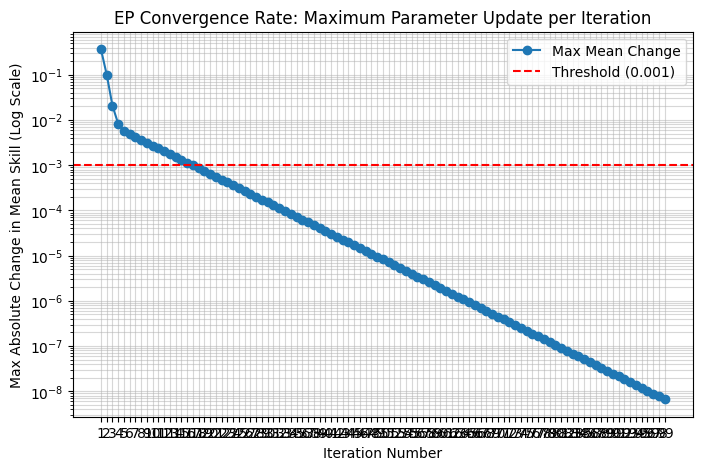

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# === EP Quantitative Convergence Check ===

# EP
#ep_result_full, _, ep_history_full = exprop(games, num_players, num_its=100, return_msg=True)

# history of mean
means_history = ep_history_full[:, :, 0]
ep_mean = ep_result_full[:, 0]
ep_var = ep_result_full[:, 1]

# calculate delta
deltas = np.abs(np.diff(means_history, axis=0))

# Max Delta
max_deltas_per_iter = np.max(deltas, axis=1)

# Tolerance
threshold = 1e-3

# find iter
converged_iter = -1
for t, max_delta in enumerate(max_deltas_per_iter):
    if max_delta < threshold:
        converged_iter = t + 1
        break

print(f"--- EP Convergence Quantitative Analysis ---")
print(f"Convergence Threshold: {threshold}")

if converged_iter != -1:
    print(f"✅ Converged at Iteration: {converged_iter}")
    print(f"   (Max parameter change was {max_deltas_per_iter[converged_iter-1]:.2e})")
else:
    print(f"❌ Did not converge within {len(max_deltas_per_iter)} iterations based on threshold.")
    print(f"   Final max change: {max_deltas_per_iter[-1]:.2e}")

# Log Scale Plot
plt.figure(figsize=(8, 5))
iters = range(1, len(max_deltas_per_iter) + 1)
plt.plot(iters, max_deltas_per_iter, marker='o', linestyle='-', label='Max Mean Change')

plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')

plt.yscale('log') # log scale
plt.xlabel('Iteration Number')
plt.ylabel('Max Absolute Change in Mean Skill (Log Scale)')
plt.title('EP Convergence Rate: Maximum Parameter Update per Iteration')
plt.xticks(iters)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

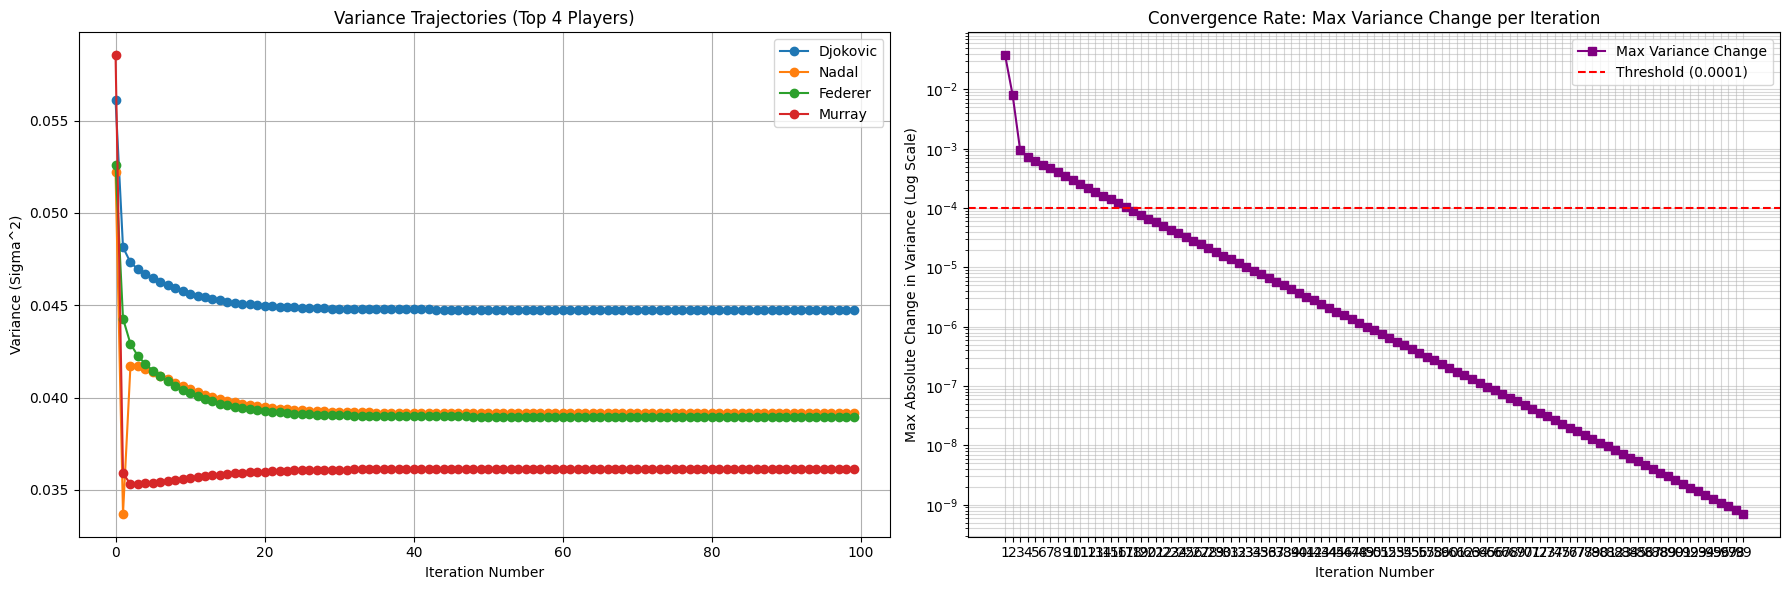

--- Variance Convergence Check ---
✅ Variance converged at Iteration: 18
   (Max variance change dropped below 0.0001)


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# === Variance Convergence Analysis ===

# data
# ep_history_full shape: (num_its, num_players, 2) -> Index 1 is var
vars_history = ep_history_full[:, :, 1]
ep_mean = ep_result_full[:, 0]
ep_var = ep_result_full[:, 1]

# calculate max
# diffs[t] = |var_{t} - var_{t-1}|
var_deltas = np.abs(np.diff(vars_history, axis=0))
# max
max_var_deltas = np.max(var_deltas, axis=1)

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ledt--Visual Proof
top4_names = ["Djokovic", "Nadal", "Federer", "Murray"]
# top4_idx = find_player_indices(W, top4_names)

for i, name in enumerate(top4_names):
    player_vars = vars_history[:, top4_idx[i]]
    ax1.plot(player_vars, marker='o', linestyle='-', label=name)

ax1.set_title("Variance Trajectories (Top 4 Players)")
ax1.set_xlabel("Iteration Number")
ax1.set_ylabel("Variance (Sigma^2)")
ax1.legend()
ax1.grid(True)

# right: Quantitative Proof
iters = range(1, len(max_var_deltas) + 1)
ax2.plot(iters, max_var_deltas, marker='s', color='purple', linestyle='-', label='Max Variance Change')

# 1e-4 threshold line
threshold = 1e-4
ax2.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')

ax2.set_yscale('log')
ax2.set_title("Convergence Rate: Max Variance Change per Iteration")
ax2.set_xlabel("Iteration Number")
ax2.set_ylabel("Max Absolute Change in Variance (Log Scale)")
ax2.set_xticks(iters)
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

# output analysis
converged_iter_var = -1
for t, delta in enumerate(max_var_deltas):
    if delta < threshold:
        converged_iter_var = t + 1
        break

print(f"--- Variance Convergence Check ---")
if converged_iter_var != -1:
    print(f"✅ Variance converged at Iteration: {converged_iter_var}")
    print(f"   (Max variance change dropped below {threshold})")
else:
    print(f"❌ Variance did not converge below threshold within {len(max_var_deltas)} iterations.")

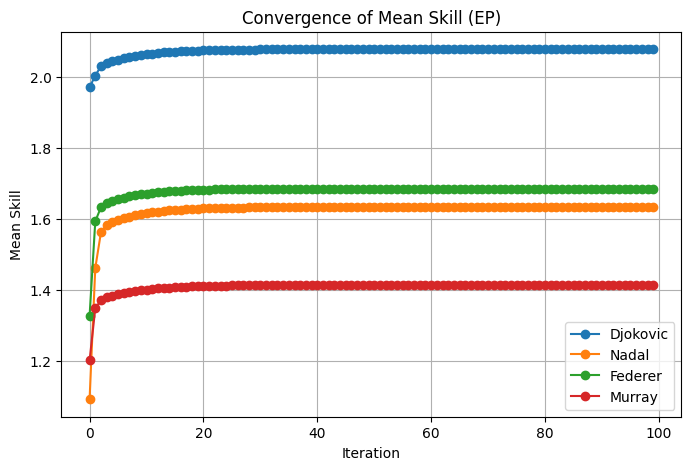

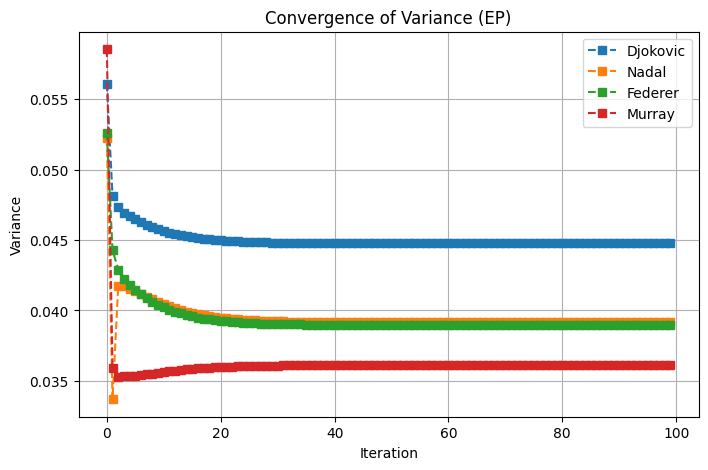

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ep_result_full, _, ep_history_full = exprop(games, num_players, num_its=10, return_msg=True)

top4_names = ["Djokovic", "Nadal", "Federer", "Murray"]
top4_idx = find_player_indices(W, top4_names)

mean_history = ep_history_full[:, top4_idx, 0]

var_history = ep_history_full[:, top4_idx, 1]

# Mean Skill Convergence
plt.figure(figsize=(8, 5))
for i, name in enumerate(top4_names):
    plt.plot(mean_history[:, i], marker='o', linestyle='-', label=name)

plt.title("Convergence of Mean Skill (EP)")
plt.xlabel("Iteration")
plt.ylabel("Mean Skill")
plt.grid(True)
plt.legend()
plt.show()

# Variance Convergence
plt.figure(figsize=(8, 5))
for i, name in enumerate(top4_names):
    plt.plot(var_history[:, i], marker='s', linestyle='--', label=name)

plt.title("Convergence of Variance (EP)")
plt.xlabel("Iteration")
plt.ylabel("Variance")
plt.grid(True)
plt.legend()
plt.show()

C:

Task (c) - Table 1: P(Skill Row > Skill Col) [EP Approx]
          Djokovic  Nadal  Federer  Murray
Djokovic     0.500  0.937    0.912   0.990
Nadal        0.063  0.500    0.426   0.788
Federer      0.088  0.574    0.500   0.839
Murray       0.010  0.212    0.161   0.500

Task (c) - Table 2: P(Row wins against Col) [EP Approx]
          Djokovic  Nadal  Federer  Murray
Djokovic     0.500  0.665    0.646   0.737
Nadal        0.334  0.500    0.480   0.584
Federer      0.353  0.520    0.500   0.603
Murray       0.261  0.416    0.397   0.500


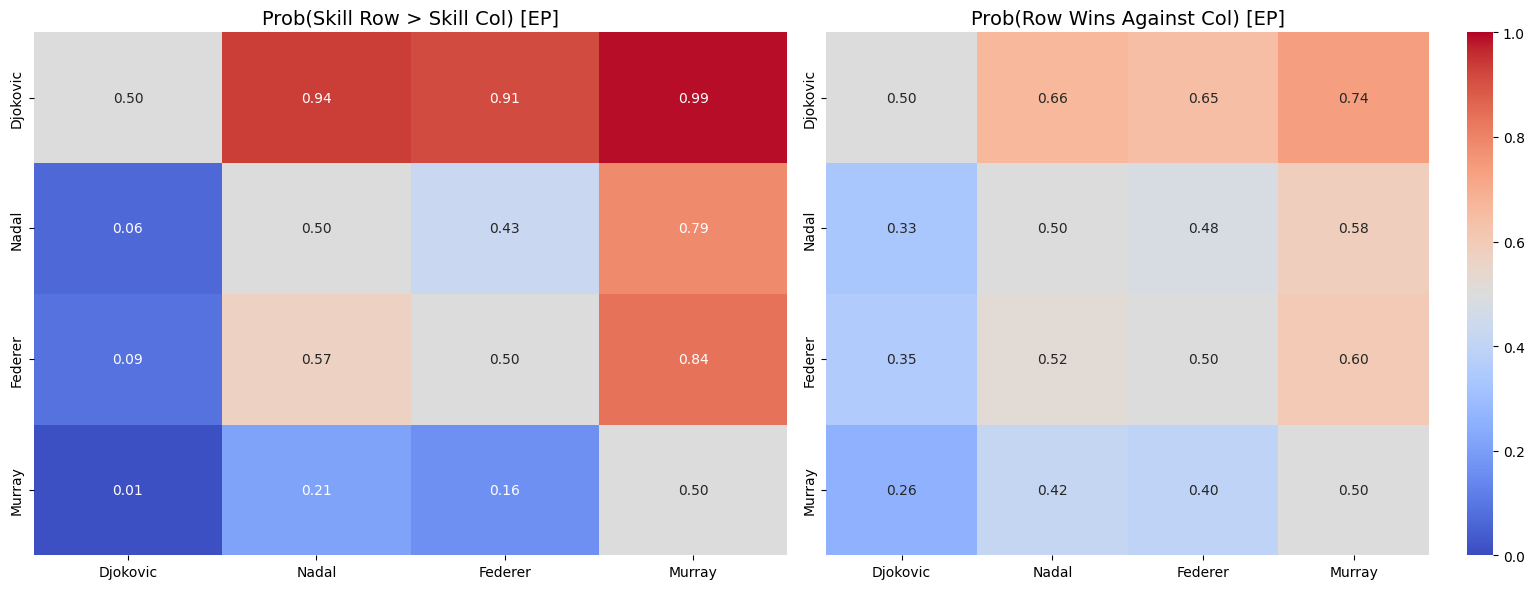

In [18]:
import seaborn as sns

top4_names = ["Djokovic", "Nadal", "Federer", "Murray"]
top4_idx = find_player_indices(W, top4_names)

mus = ep_mean[top4_idx]
vars = ep_var[top4_idx]

n = len(top4_names)
table_skill = np.zeros((n, n))
table_win = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j: continue

        # Table 1: P(skill_i > skill_j)
        table_skill[i, j] = prob_skill_higher(mus[i], vars[i], mus[j], vars[j])

        # Table 2: P(i wins against j)
        table_win[i, j] = prob_player_wins(mus[i], vars[i], mus[j], vars[j])

np.fill_diagonal(table_skill, 0.5)
np.fill_diagonal(table_win, 0.5)

print("Task (c) - Table 1: P(Skill Row > Skill Col) [EP Approx]")
print(pd.DataFrame(table_skill, index=top4_names, columns=top4_names).round(3))
print("\nTask (c) - Table 2: P(Row wins against Col) [EP Approx]")
print(pd.DataFrame(table_win, index=top4_names, columns=top4_names).round(3))

# plot
df_skill = pd.DataFrame(table_skill, index=top4_names, columns=top4_names)
df_win = pd.DataFrame(table_win, index=top4_names, columns=top4_names)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# P(Skill > Skill)
sns.heatmap(df_skill, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, ax=ax[0], cbar=False)
ax[0].set_title("Prob(Skill Row > Skill Col) [EP]", fontsize=14)

# P(Win)
sns.heatmap(df_win, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, ax=ax[1])
ax[1].set_title("Prob(Row Wins Against Col) [EP]", fontsize=14)

plt.tight_layout()
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1101196240.py:44: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, y_skill, label=f'Skill Difference ($w_N - w_D$)\n$\sigma^2 \\approx {std_skill**2:.2f}$', linewidth=2.5)
/tmp/ipython-input-1101196240.py:45: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, y_perf, label=f'Performance Difference ($t_N - t_D$)\n$\sigma^2 \\approx {std_perf**2:.2f}$', linewidth=2.5, linestyle='--')


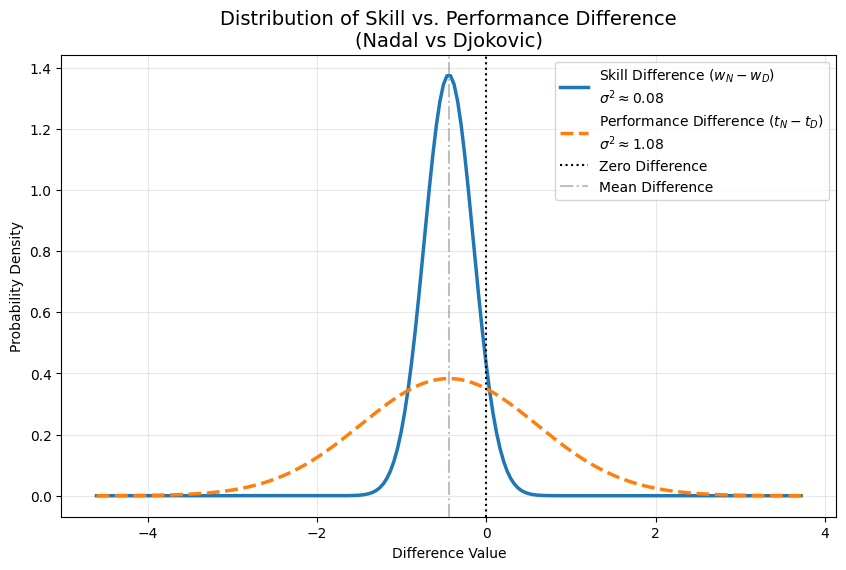

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# top4_names = ["Djokovic", "Nadal", "Federer", "Murray"]
# top4_idx = find_player_indices(W, top4_names)

p1_name = "Nadal"
p2_name = "Djokovic"
p1_idx = find_player_indices(W, [p1_name])[0]
p2_idx = find_player_indices(W, [p2_name])[0]

mu_1, var_1 = ep_mean[p1_idx], ep_var[p1_idx]
mu_2, var_2 = ep_mean[p2_idx], ep_var[p2_idx]

# 2 Guassian
# Mean Difference
mu_diff = mu_1 - mu_2

# A. Skill Difference s = w1 - w2
# Variance = sigma_1^2 + sigma_2^2
std_skill = np.sqrt(var_1 + var_2)

# B. Performance Difference t = w1 - w2 + n
# Variance = sigma_1^2 + sigma_2^2 + 1
std_perf = np.sqrt(var_1 + var_2 + 1.0)

# plot
x = np.linspace(mu_diff - 4*std_perf, mu_diff + 4*std_perf, 200)

# PDF
y_skill = norm.pdf(x, mu_diff, std_skill)
y_perf = norm.pdf(x, mu_diff, std_perf)

plt.figure(figsize=(10, 6))

plt.plot(x, y_skill, label=f'Skill Difference ($w_N - w_D$)\n$\sigma^2 \\approx {std_skill**2:.2f}$', linewidth=2.5)
plt.plot(x, y_perf, label=f'Performance Difference ($t_N - t_D$)\n$\sigma^2 \\approx {std_perf**2:.2f}$', linewidth=2.5, linestyle='--')

plt.axvline(0, color='k', linestyle=':', label='Zero Difference')
plt.axvline(mu_diff, color='gray', linestyle='-.', alpha=0.5, label='Mean Difference')

plt.title(f"Distribution of Skill vs. Performance Difference\n({p1_name} vs {p2_name})", fontsize=14)
plt.xlabel("Difference Value")
plt.ylabel("Probability Density")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

D:

In [29]:
# clean_samples (without Burn-in)
# burn_in = 500; clean_samples = skill_samples[:, burn_in:]

nadal_idx = find_player_indices(W, ["Djokovic"])[0]
federer_idx = find_player_indices(W, ["Nadal"])[0]

samples_n = clean_samples[nadal_idx, :]
samples_f = clean_samples[federer_idx, :]

# compare

# 1. Marginal Gaussian Approximation
mu_n, var_n = np.mean(samples_n), np.var(samples_n)
mu_f, var_f = np.mean(samples_f), np.var(samples_f)
prob_marginal = prob_skill_higher(mu_n, var_n, mu_f, var_f)

# 2. Joint Gaussian Approximation
# N(mu_N - mu_F, Var(w_N - w_F))
diff_samples = samples_n - samples_f
mu_diff = np.mean(diff_samples)
std_diff = np.std(diff_samples)
prob_joint = norm.cdf(mu_diff / std_diff)

# 3. Empirical
prob_empirical = np.mean(samples_n > samples_f)

print("Task (d) - Djokovic vs Nadal: P(Skill Djokovic > Skill Nadal)")
print(f"1. Marginal Approx (Ignored Corr): {prob_marginal:.4f}")
print(f"2. Joint Approx (Captured Corr):   {prob_joint:.4f}")
print(f"3. Empirical (Samples):            {prob_empirical:.4f}")

Task (d) - Djokovic vs Nadal: P(Skill Djokovic > Skill Nadal)
1. Marginal Approx (Ignored Corr): 0.9375
2. Joint Approx (Captured Corr):   0.9645
3. Empirical (Samples):            0.9591


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-929942051.py:26: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, y_1, label=f'{p1_name} ($\mu$={mu_1:.2f}, $\sigma$={std_1:.2f})', lw=2)
/tmp/ipython-input-929942051.py:26: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, y_1, label=f'{p1_name} ($\mu$={mu_1:.2f}, $\sigma$={std_1:.2f})', lw=2)
/tmp/ipython-input-929942051.py:27: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, y_2, label=f'{p2_name} ($\mu$={mu_2:.2f}, $\sigma$={std_2:.2f})', lw=2)
/tmp/ipython-input-929942051.py:27: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, 

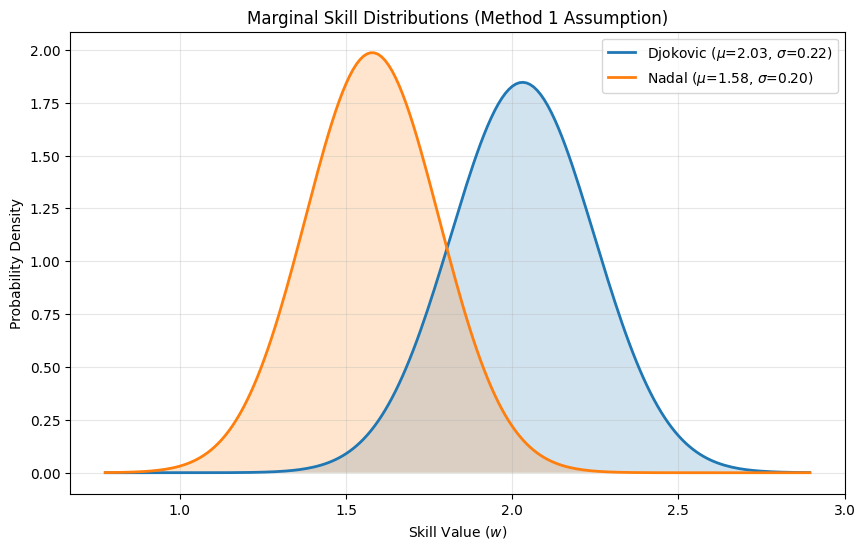

Covariance between Djokovic and Nadal: 0.0121


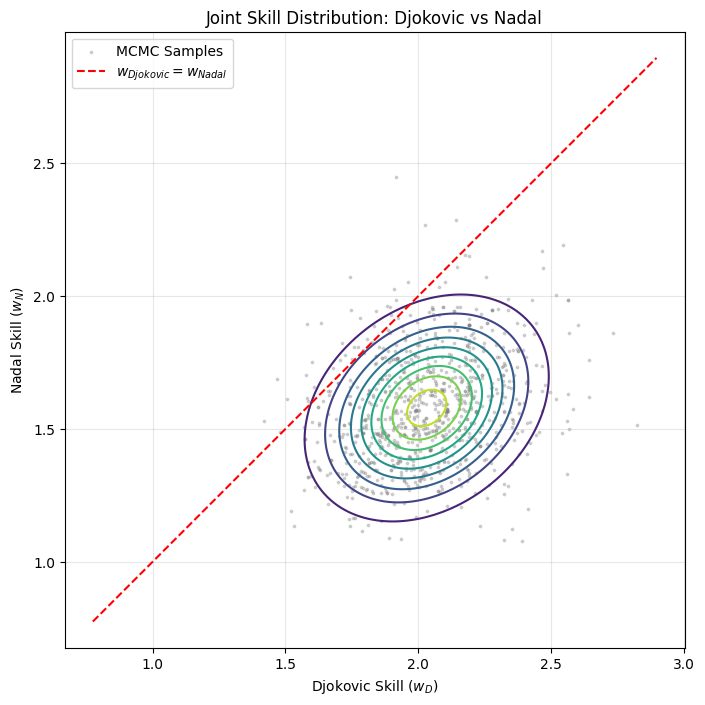

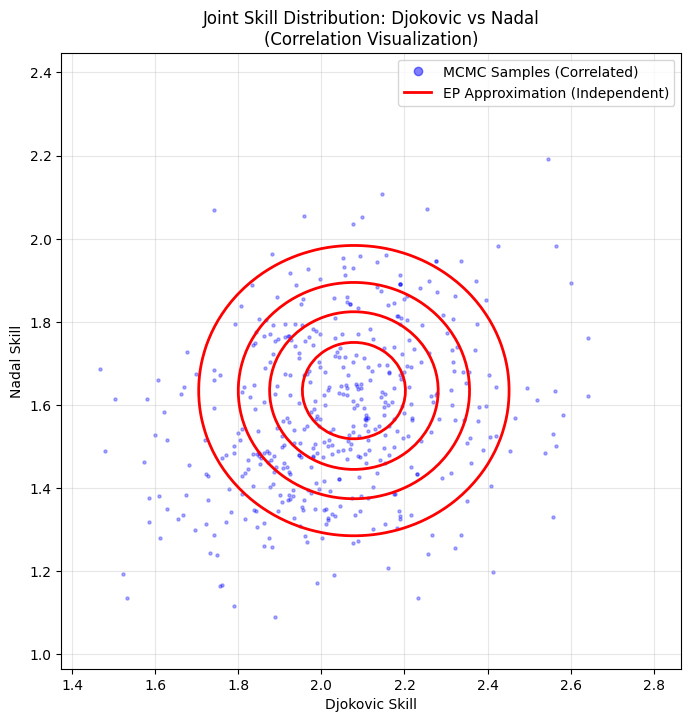

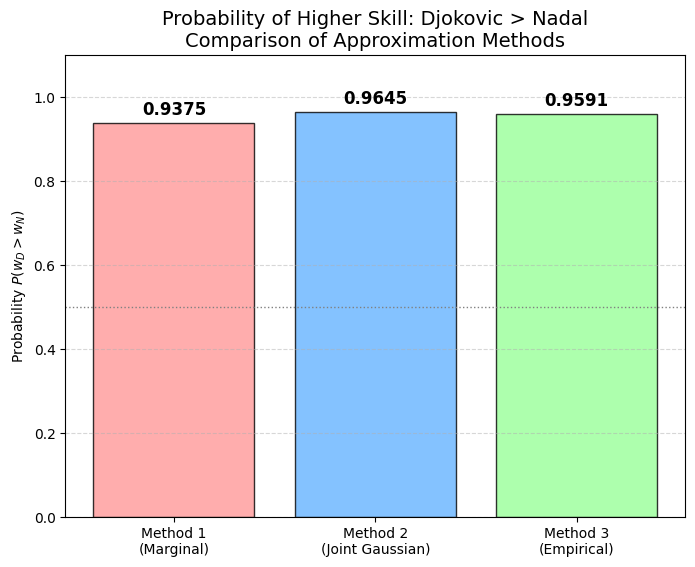

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

p1_name = "Djokovic"
p2_name = "Nadal"
p1_idx = find_player_indices(W, [p1_name])[0]
p2_idx = find_player_indices(W, [p2_name])[0]

samples_1 = clean_samples[p1_idx, :]
samples_2 = clean_samples[p2_idx, :]

mu_1, std_1 = np.mean(samples_1), np.std(samples_1)
mu_2, std_2 = np.mean(samples_2), np.std(samples_2)

# Marginal Distributions
plt.figure(figsize=(10, 6))

x_min = min(mu_1 - 4*std_1, mu_2 - 4*std_2)
x_max = max(mu_1 + 4*std_1, mu_2 + 4*std_2)
x = np.linspace(x_min, x_max, 200)

y_1 = norm.pdf(x, mu_1, std_1)
y_2 = norm.pdf(x, mu_2, std_2)

plt.plot(x, y_1, label=f'{p1_name} ($\mu$={mu_1:.2f}, $\sigma$={std_1:.2f})', lw=2)
plt.plot(x, y_2, label=f'{p2_name} ($\mu$={mu_2:.2f}, $\sigma$={std_2:.2f})', lw=2)
plt.fill_between(x, y_1, alpha=0.2)
plt.fill_between(x, y_2, alpha=0.2)

plt.title("Marginal Skill Distributions (Method 1 Assumption)")
plt.xlabel("Skill Value ($w$)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Joint Skill Distribution

joint_samples = np.vstack([samples_1, samples_2])
cov_matrix = np.cov(joint_samples)
mean_vector = [mu_1, mu_2]

print(f"Covariance between {p1_name} and {p2_name}: {cov_matrix[0,1]:.4f}")

x_range = np.linspace(mu_1 - 3*std_1, mu_1 + 3*std_1, 100)
y_range = np.linspace(mu_2 - 3*std_2, mu_2 + 3*std_2, 100)
X, Y = np.meshgrid(x_range, y_range)
pos = np.dstack((X, Y))

rv = multivariate_normal(mean_vector, cov_matrix)
Z = rv.pdf(pos)

plt.figure(figsize=(8, 8))

contour = plt.contour(X, Y, Z, levels=10, cmap='viridis')
# plt.clabel(contour, inline=1, fontsize=8)

plt.scatter(samples_1[::5], samples_2[::5], s=3, alpha=0.3, color='gray', label='MCMC Samples')

lims = [min(x_min, x_min), max(x_max, x_max)]
plt.plot(lims, lims, 'r--', label='$w_{Djokovic} = w_{Nadal}$')

plt.title(f"Joint Skill Distribution: {p1_name} vs {p2_name}")
plt.xlabel(f"{p1_name} Skill ($w_D$)")
plt.ylabel(f"{p2_name} Skill ($w_N$)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.axis('equal')

plt.show()

from matplotlib.lines import Line2D
idx1 = top4_idx[0] # Djokovic
idx2 = top4_idx[1] # Nadal

x_mcmc = clean_samples[idx1, :]
y_mcmc = clean_samples[idx2, :]

x_grid = np.linspace(np.min(x_mcmc), np.max(x_mcmc), 100)
y_grid = np.linspace(np.min(y_mcmc), np.max(y_mcmc), 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = norm.pdf(X, mus[0], np.sqrt(vars[0])) * norm.pdf(Y, mus[1], np.sqrt(vars[1]))

plt.figure(figsize=(8, 8))

plt.contour(X, Y, Z, levels=5, colors='red', linewidths=2)

plt.scatter(x_mcmc[::10], y_mcmc[::10], s=5, alpha=0.3, color='blue')

plt.title(f"Joint Skill Distribution: {top4_names[0]} vs {top4_names[1]}\n(Correlation Visualization)")
plt.xlabel(f"{top4_names[0]} Skill")
plt.ylabel(f"{top4_names[1]} Skill")

custom_lines = [Line2D([0], [0], color='blue', marker='o', linestyle='None', alpha=0.5),
                Line2D([0], [0], color='red', lw=2)]
plt.legend(custom_lines, ['MCMC Samples (Correlated)', 'EP Approximation (Independent)'])

plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

methods = ['Method 1\n(Marginal)', 'Method 2\n(Joint Gaussian)', 'Method 3\n(Empirical)']
probs = [prob_marginal, prob_joint, prob_empirical]
colors = ['#ff9999', '#66b3ff', '#99ff99']

plt.figure(figsize=(8, 6))
bars = plt.bar(methods, probs, color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title(f"Probability of Higher Skill: {p1_name} > {p2_name}\nComparison of Approximation Methods", fontsize=14)
plt.ylabel("Probability $P(w_D > w_N)$")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.axhline(0.5, color='gray', linestyle=':', linewidth=1)

plt.show()

Task (d) - MCMC Empirical P(Skill Row > Skill Col
          Djokovic  Nadal  Federer  Murray
Djokovic     0.500  0.959    0.932   0.990
Nadal        0.041  0.500    0.428   0.770
Federer      0.068  0.572    0.500   0.816
Murray       0.010  0.230    0.184   0.500

Task (d) - EP Marginal P(Skill Row > Skill Col)
          Djokovic  Nadal  Federer  Murray
Djokovic     0.500  0.937    0.912   0.990
Nadal        0.063  0.500    0.426   0.788
Federer      0.088  0.574    0.500   0.839
Murray       0.010  0.212    0.161   0.500


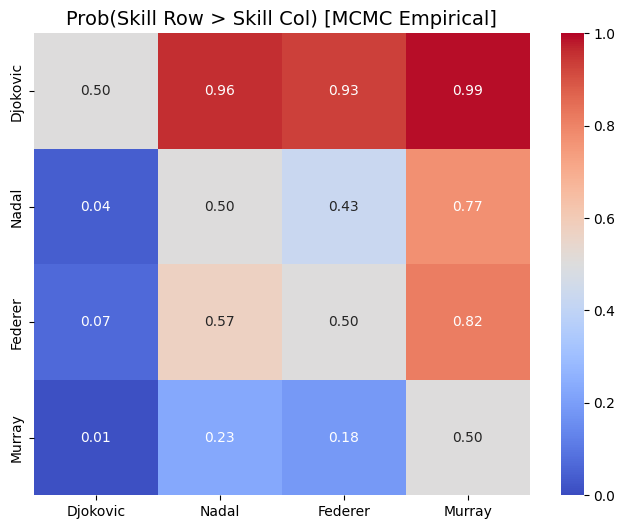

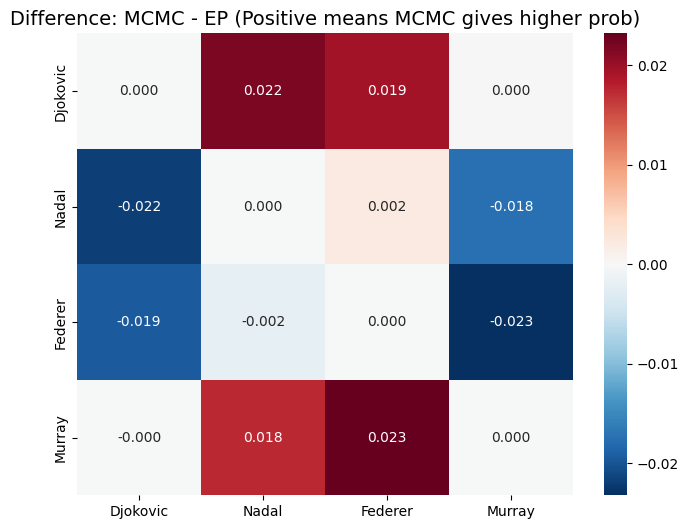

In [25]:
# MCMC skill table generation

top4_names = ["Djokovic", "Nadal", "Federer", "Murray"]
top4_idx = find_player_indices(W, top4_names)
top4_samples = clean_samples[top4_idx, :] # 4 x num_samples

n = len(top4_names)
table_mcmc = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            table_mcmc[i, j] = 0.5
            continue

        # Method 3: P(w_i > w_j)
        table_mcmc[i, j] = np.mean(top4_samples[i] > top4_samples[j])

print("Task (d) - MCMC Empirical P(Skill Row > Skill Col")
print(pd.DataFrame(table_mcmc, index=top4_names, columns=top4_names).round(3))

# ep result
mus_ep = ep_mean[top4_idx]
vars_ep = ep_var[top4_idx]
table_ep = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
          table_ep[i, j] = 0.5
          continue
        table_ep[i, j] = prob_skill_higher(mus_ep[i], vars_ep[i], mus_ep[j], vars_ep[j])

print("\nTask (d) - EP Marginal P(Skill Row > Skill Col)")
df_ep = pd.DataFrame(table_ep, index=top4_names, columns=top4_names)
print(df_ep.round(3))

# Plot

# MCMC Heatmap
plt.figure(figsize=(8, 6))
df_mcmc = pd.DataFrame(table_mcmc, index=top4_names, columns=top4_names)
sns.heatmap(df_mcmc, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Prob(Skill Row > Skill Col) [MCMC Empirical]", fontsize=14)
plt.show()

# Difference Heatmap (MCMC - EP)
diff = df_mcmc - df_ep

plt.figure(figsize=(8, 6))
sns.heatmap(diff, annot=True, fmt=".3f", cmap="RdBu_r", center=0)
plt.title("Difference: MCMC - EP (Positive means MCMC gives higher prob)", fontsize=14)
plt.show()

E：

Plot 1: Empirical Win Rate Ranking


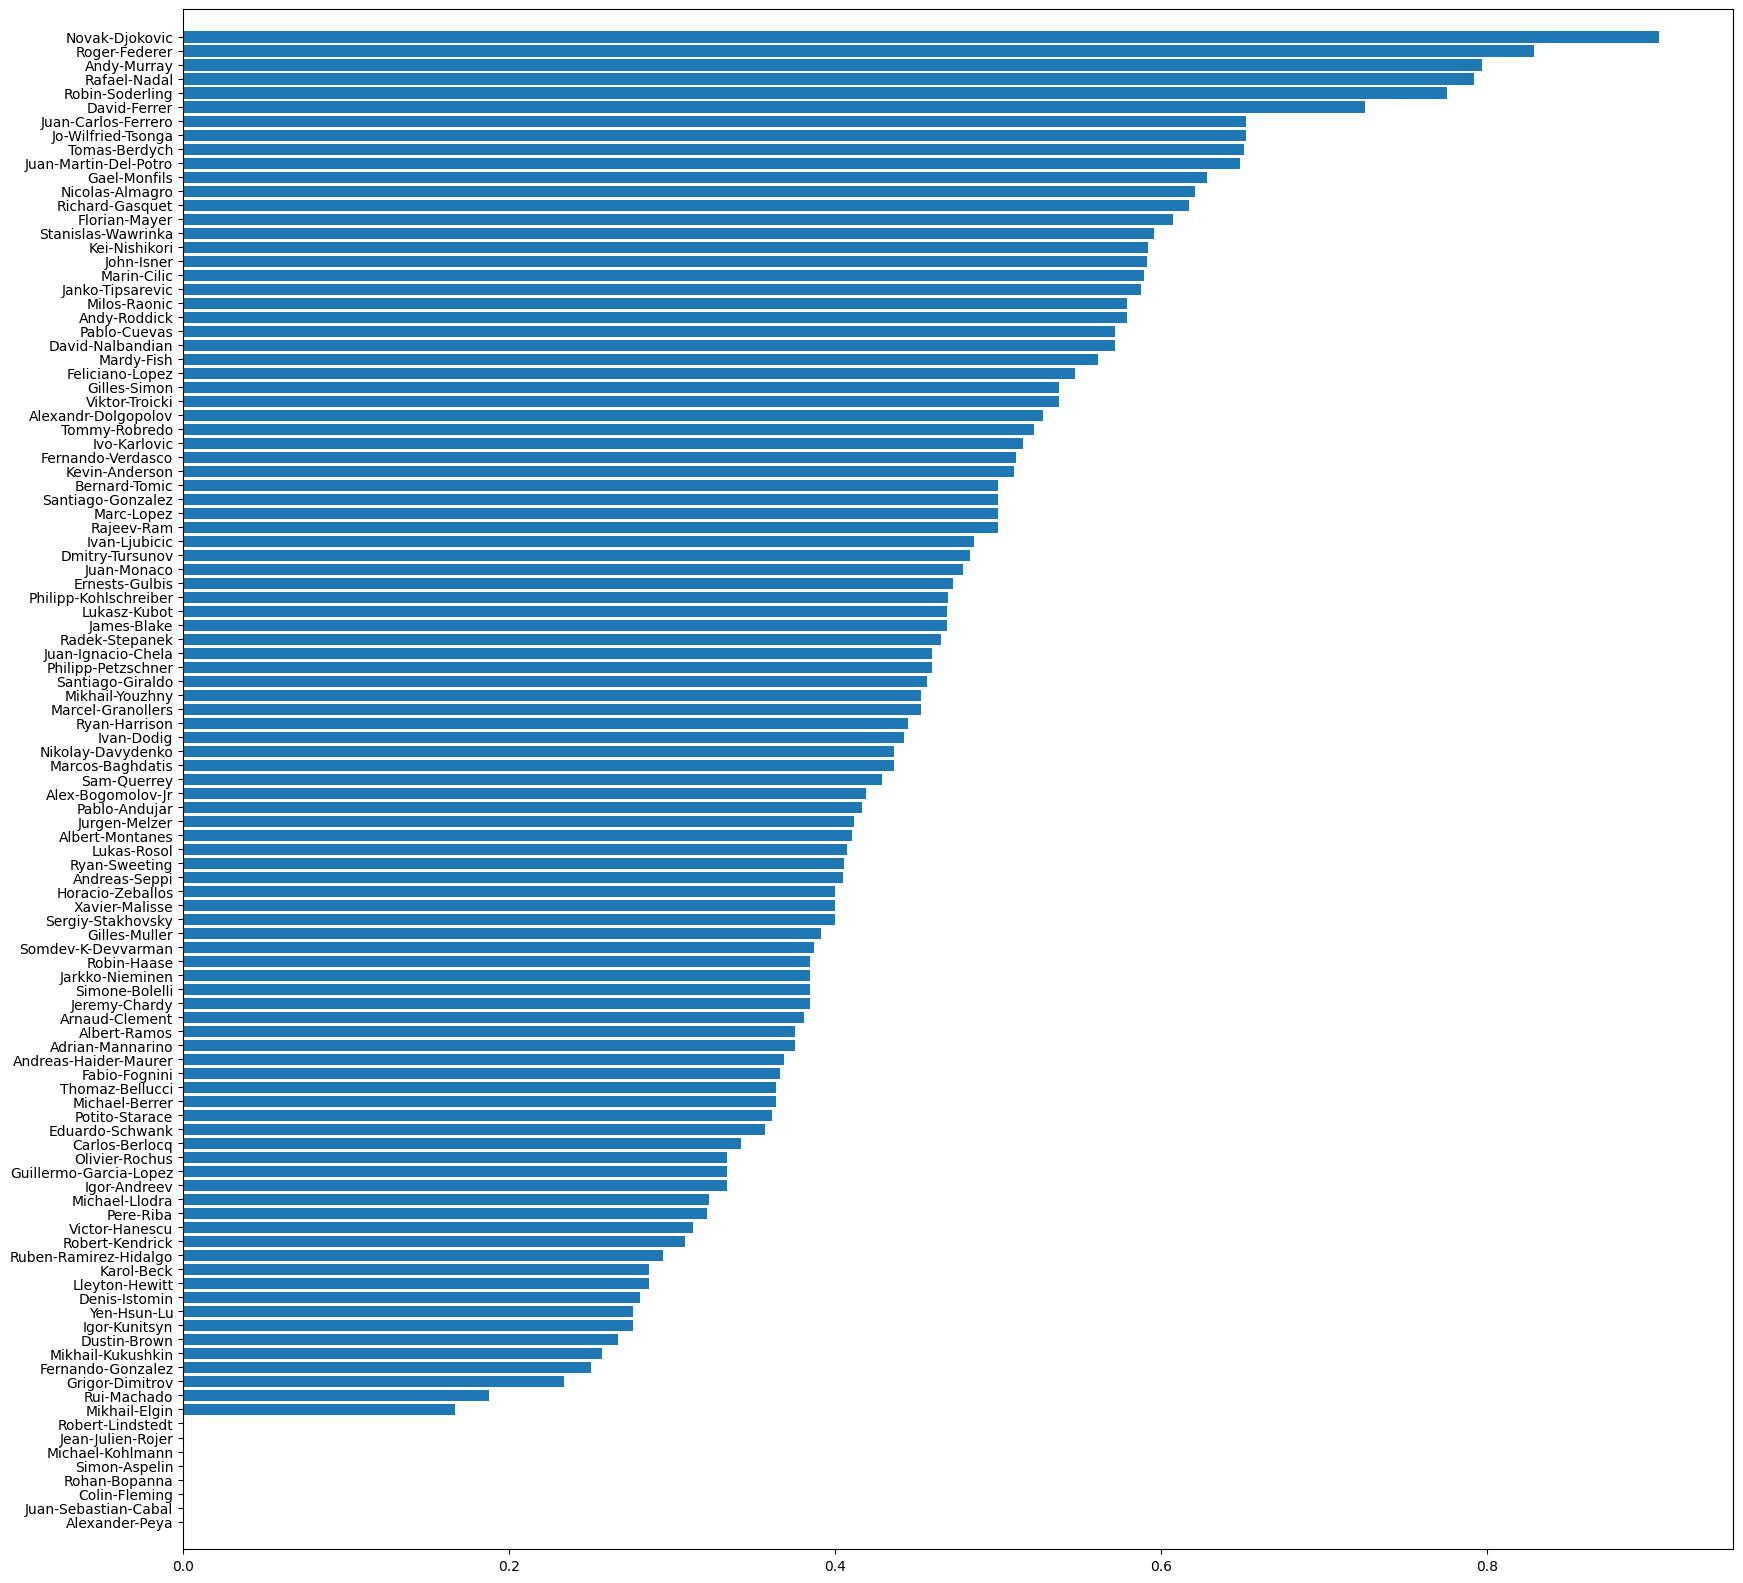

Plot 2: MCMC Mean Skill Ranking


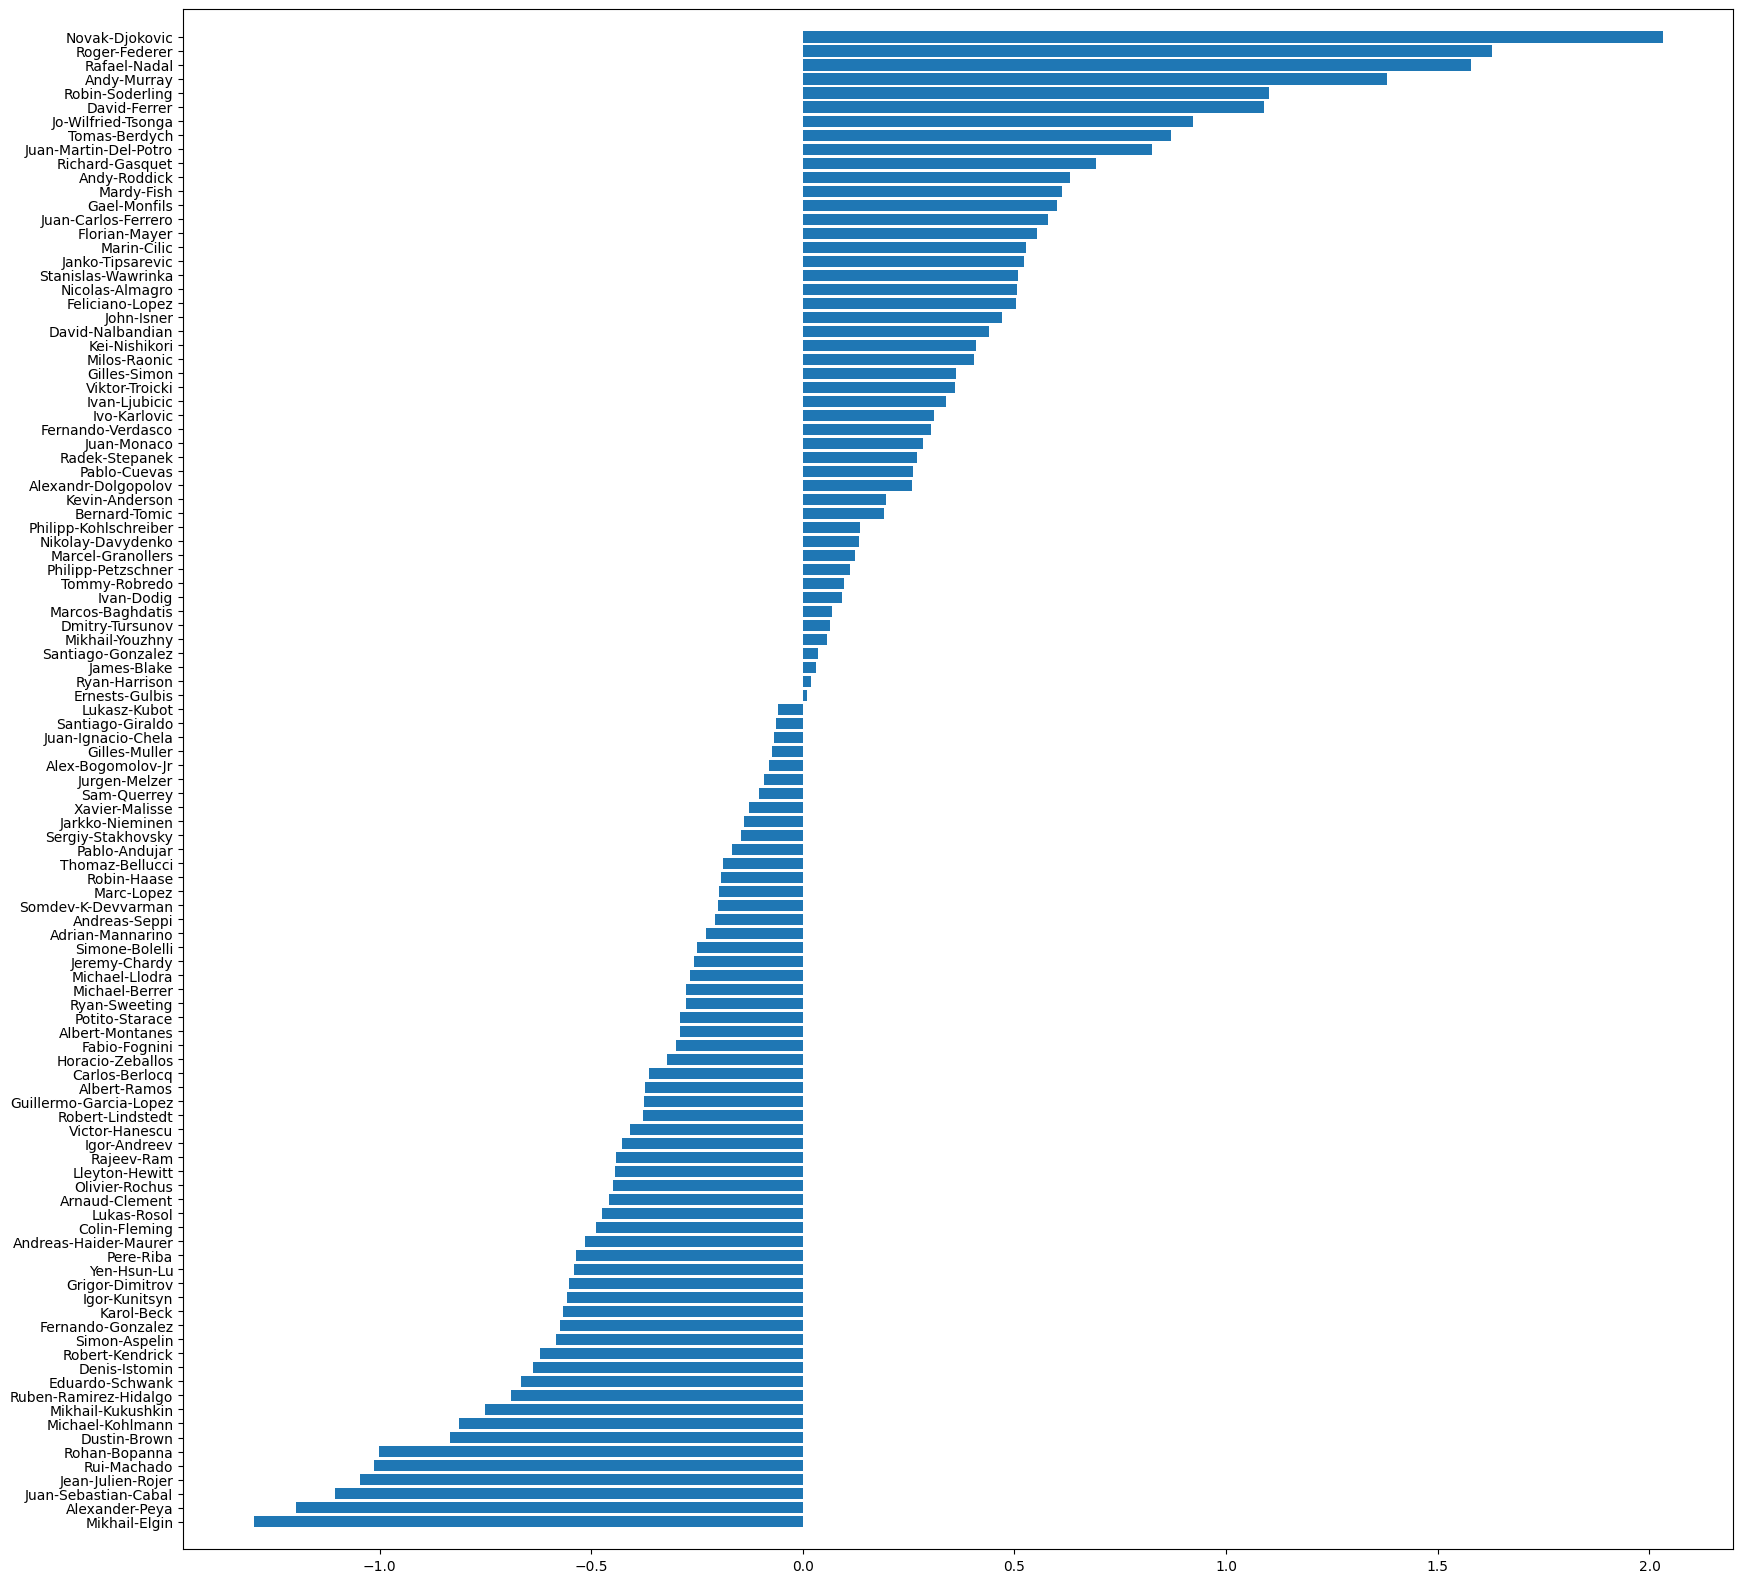

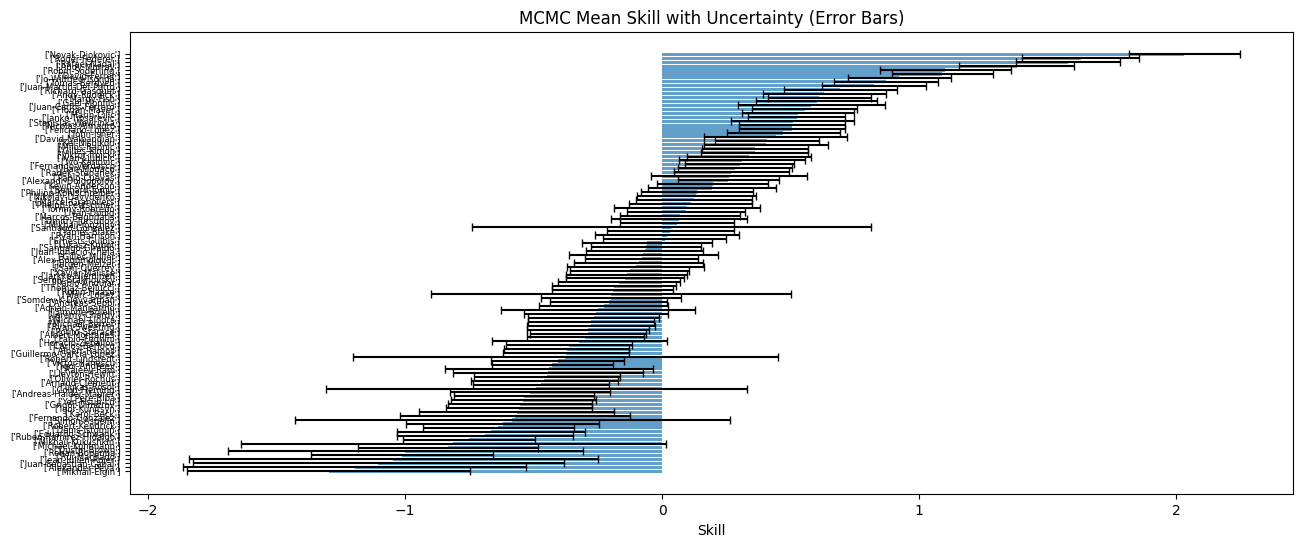

Plot 3: EP Mean Skill Ranking


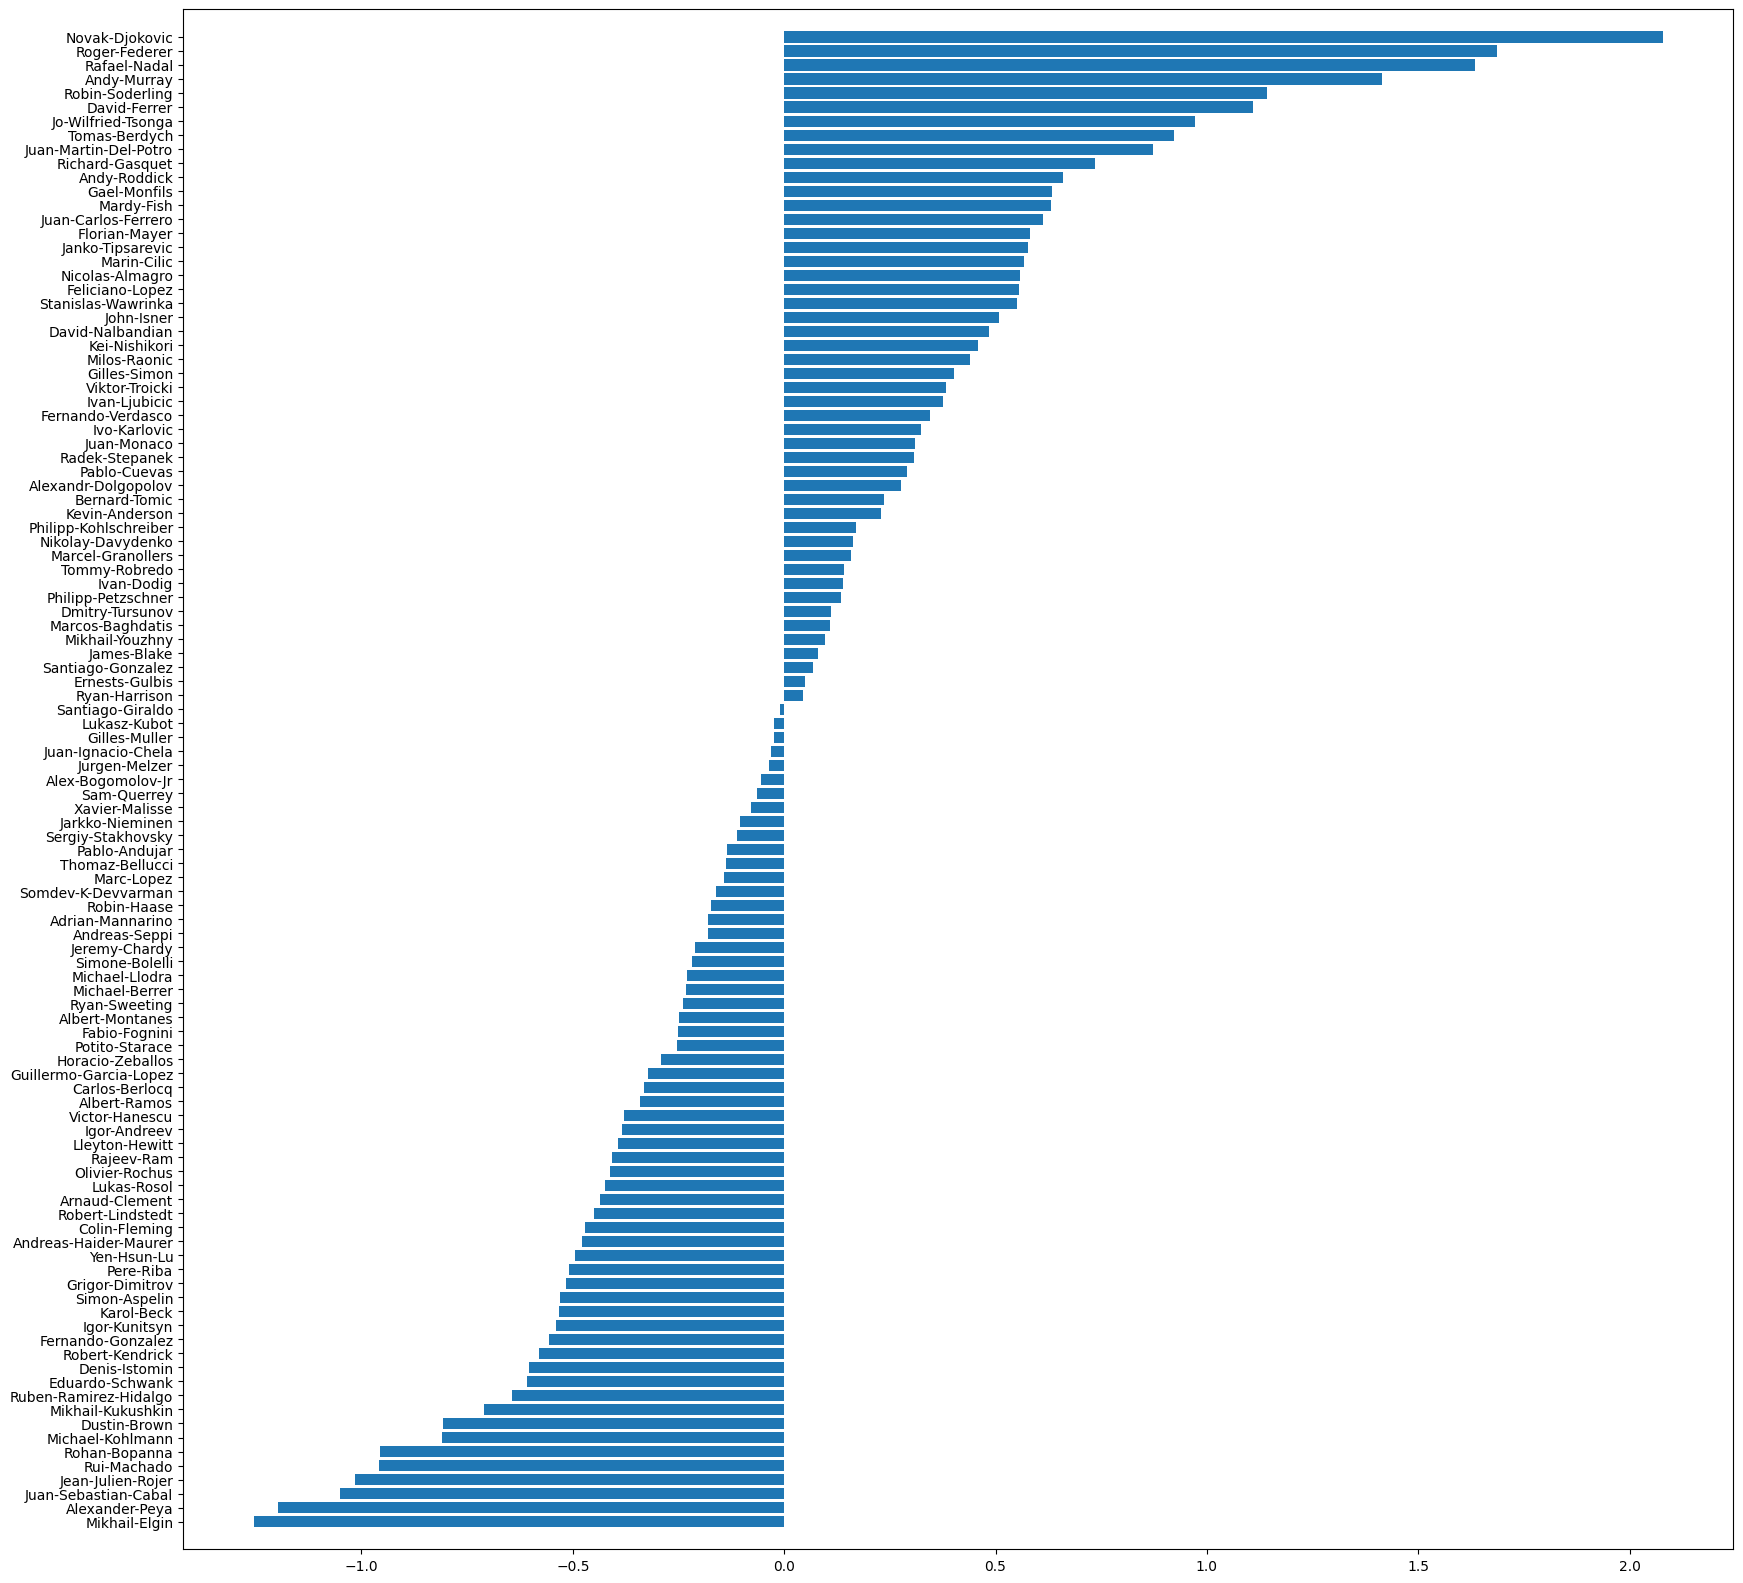

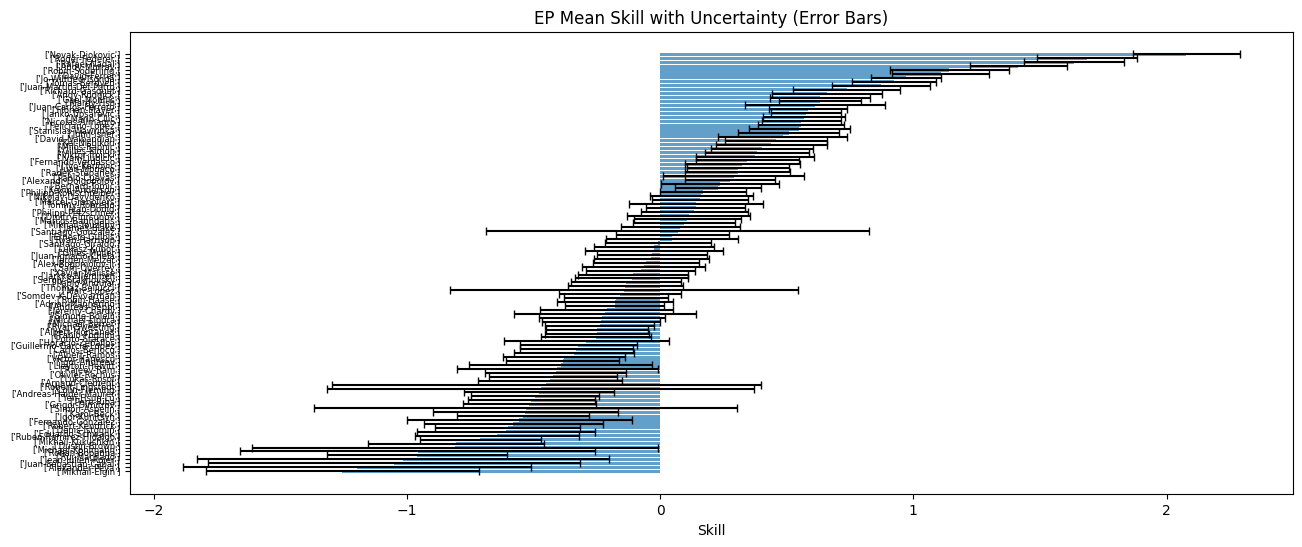

In [13]:
# 1. Empirical Game Outcome Averages (Win Rate)
wins = np.zeros(num_players)
total_games = np.zeros(num_players)
# games is (winner, loser) pairs
for game in games:
    winner, loser = game
    # Winner's stats
    wins[winner] += 1
    total_games[winner] += 1
    # Loser's stats
    total_games[loser] += 1

win_ratio = np.divide(wins, total_games, out=np.zeros_like(wins, dtype=float), where=total_games!=0)

print("Plot 1: Empirical Win Rate Ranking")
sorted_barplot(win_ratio, W)

# 2. Predictions based on Monte Carlo sampling (Mean Skill)
mcmc_mean_skills = np.mean(clean_samples, axis=1)

print("Plot 2: MCMC Mean Skill Ranking")
sorted_barplot(mcmc_mean_skills, W)

mcmc_std_skills = np.std(clean_samples, axis=1)

perm_mcmc = np.argsort(mcmc_mean_skills)
# plot
plt.figure(figsize=(15, 6))
plt.barh(range(num_players), mcmc_mean_skills[perm_mcmc], xerr=mcmc_std_skills[perm_mcmc], align='center', alpha=0.7, ecolor='black', capsize=3)
plt.yticks(range(num_players), W[perm_mcmc], fontsize=6)
plt.title("MCMC Mean Skill with Uncertainty (Error Bars)")
plt.xlabel("Skill")
plt.show()

# 3. Predictions based on Message Passing (Mean Skill)
print("Plot 3: EP Mean Skill Ranking")
sorted_barplot(ep_mean, W)
# ep_var
ep_std = np.sqrt(ep_var)

perm_ep = np.argsort(ep_mean)
plt.figure(figsize=(15, 6))
plt.barh(range(num_players), ep_mean[perm_ep], xerr=ep_std[perm_ep], align='center', alpha=0.7, ecolor='black', capsize=3)
plt.yticks(range(num_players), W[perm_ep], fontsize=6)
plt.title("EP Mean Skill with Uncertainty (Error Bars)")
plt.xlabel("Skill")
plt.show()
